In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

file_path = "~/Desktop/Shopping_Trends.csv"
df = pd.read_csv(file_path)


print(f"Dataset Shape: {df.shape}")
print("\nColumn Names:")
print(df.columns.tolist())


print("\nFirst 5 rows of data:")
display(df.head())

#data types
print("\nData Types:")
display(df.dtypes)

#stats
print("\nSummary Statistics:")
display(df.describe(include='all').T)

#any missing data
print("\nMissing Values:")
display(df.isnull().sum())


Dataset Shape: (3900, 20)

Column Names:
['Customer ID', 'Age', 'Gender', 'Item Purchased', 'Category', 'Purchase Amount (USD)', 'Location', 'Size', 'Color', 'Season', 'Review Rating', 'Payment Method', 'Shipping Type', 'Previous Purchases', 'Preferred Payment Method', 'Frequency of Purchases', 'Customer Segmentation', 'Seasonal Trends', 'Delivery Time', 'Number of Items Purchased']

First 5 rows of data:


,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Payment Method,Shipping Type,Previous Purchases,Preferred Payment Method,Frequency of Purchases,Customer Segmentation,Seasonal Trends,Delivery Time,Number of Items Purchased
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Credit Card,Express,14,Venmo,Fortnightly,VIP,Christmas present,14,2
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Bank Transfer,Express,2,Cash,Fortnightly,VIP,Christmas present,20,4
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Cash,Free Shipping,23,Credit Card,Weekly,VIP,Summer preperation,20,2
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,PayPal,Next Day Air,49,PayPal,Weekly,New,Christmas present,7,1
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Cash,Free Shipping,31,PayPal,Annually,Loyal,Pre-fall shopping,18,7



Data Types:


Customer ID                    int64
Age                            int64
Gender                        object
Item Purchased                object
Category                      object
Purchase Amount (USD)          int64
Location                      object
Size                          object
Color                         object
Season                        object
Review Rating                float64
Payment Method                object
Shipping Type                 object
Previous Purchases             int64
Preferred Payment Method      object
Frequency of Purchases        object
Customer Segmentation         object
Seasonal Trends               object
Delivery Time                  int64
Number of Items Purchased      int64
dtype: object


Summary Statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Customer ID,3900.0,NaN,NaN,NaN,1950.5,1125.977353,1.0,975.75,1950.5,2925.25,3900.0
Age,3900.0,NaN,NaN,NaN,44.068462,15.207589,18.0,31.0,44.0,57.0,70.0
Gender,3900,2,Male,2652,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Item Purchased,3900,25,Blouse,171,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Category,3900,4,Clothing,1737,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Purchase Amount (USD),3900.0,NaN,NaN,NaN,59.764359,23.685392,20.0,39.0,60.0,81.0,100.0
Location,3900,50,Montana,96,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Size,3900,4,M,1755,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Color,3900,25,Olive,177,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Season,3900,4,Spring,999,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Missing Values:


Customer ID                  0
Age                          0
Gender                       0
Item Purchased               0
Category                     0
Purchase Amount (USD)        0
Location                     0
Size                         0
Color                        0
Season                       0
Review Rating                0
Payment Method               0
Shipping Type                0
Previous Purchases           0
Preferred Payment Method     0
Frequency of Purchases       0
Customer Segmentation        0
Seasonal Trends              0
Delivery Time                0
Number of Items Purchased    0
dtype: int64

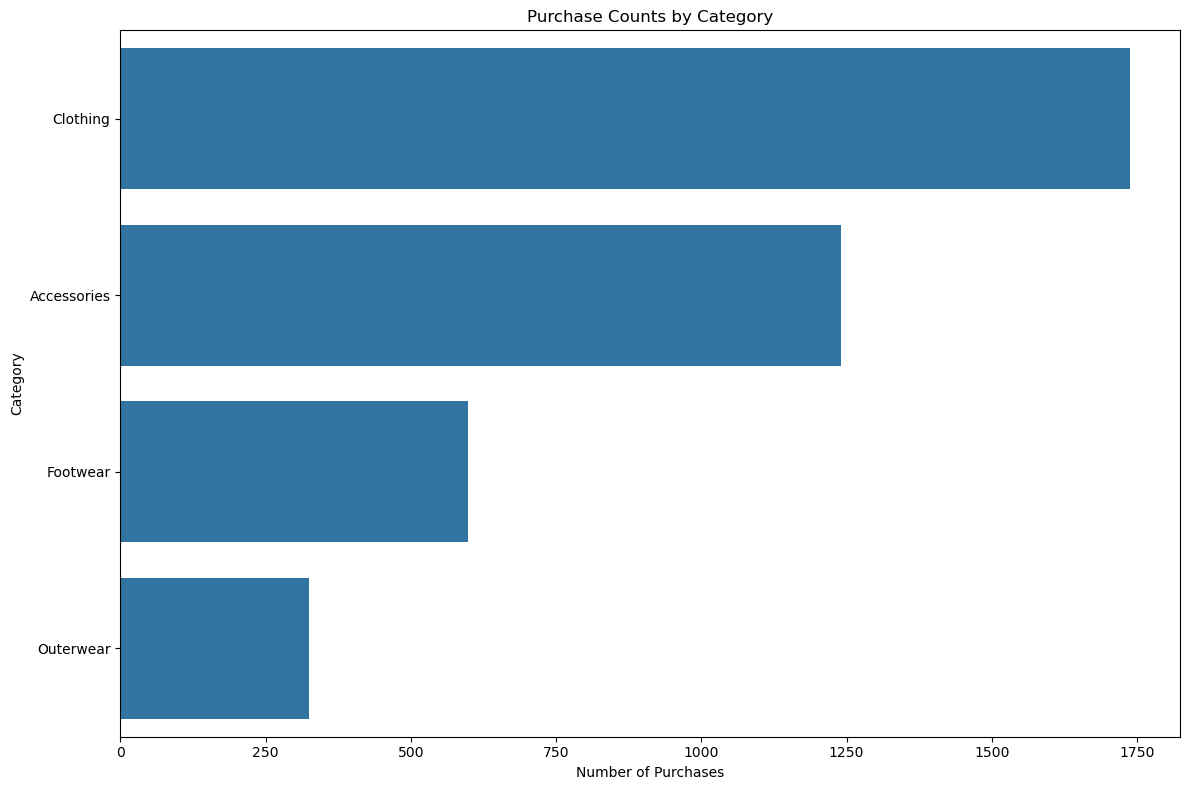

In [37]:
plt.figure(figsize=(12, 8))
category_counts = df['Category'].value_counts()
sns.barplot(x=category_counts.values, y=category_counts.index)
plt.title('Purchase Counts by Category')
plt.xlabel('Number of Purchases')
plt.tight_layout()
plt.show()


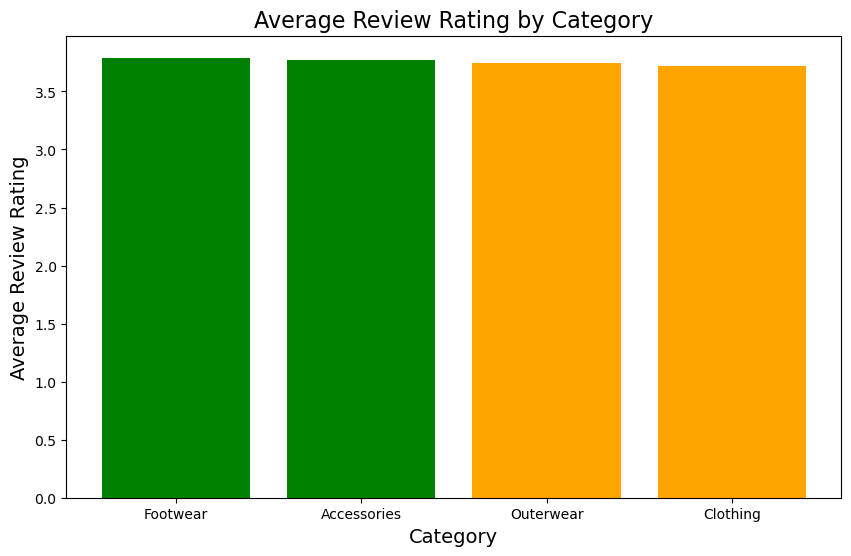

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


avg_ratings = df.groupby('Category')['Review Rating'].mean().sort_values(ascending=False)
plt.figure(figsize=(10, 6))
bars = plt.bar(avg_ratings.index, avg_ratings.values, color=['green' if r > 3.75 else 'orange' if r > 3.5 else 'red' for r in avg_ratings.values])
plt.title('Average Review Rating by Category', fontsize=16)
plt.xlabel('Category', fontsize=14)
plt.ylabel('Average Review Rating', fontsize=14)
plt.show()


RANDOM FOREST --> DETERMINE WHAT TO ADVERTISE


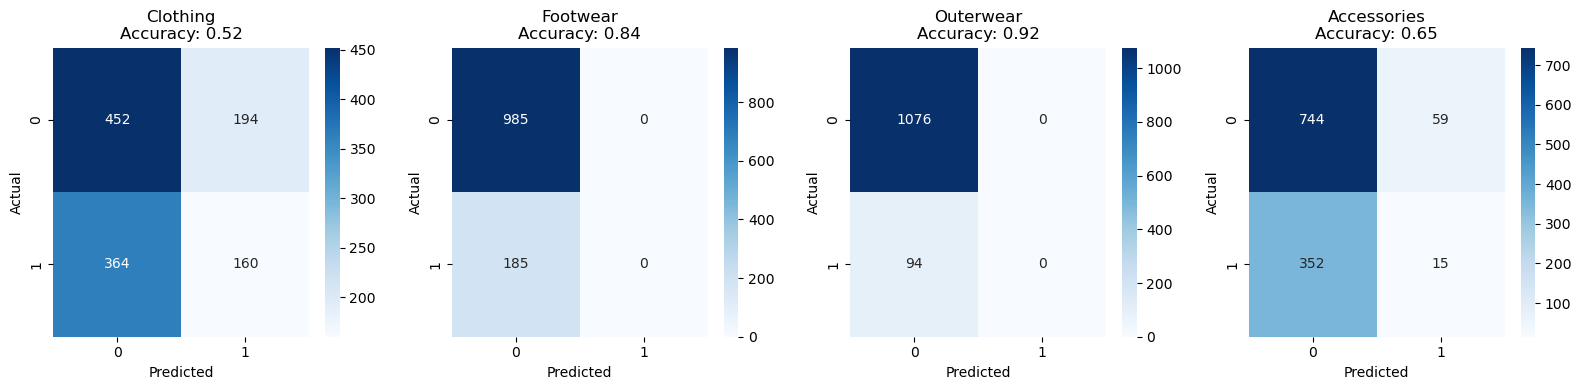


Random Forest Results for Each Category:
   Category  Accuracy  Feature_Importance  Predicted_Buyers  Actual_Buyers
   Clothing  0.523077            0.142857               354            524
   Footwear  0.841880            0.142857                 0            185
  Outerwear  0.919658            0.142857                 0             94
Accessories  0.648718            0.142857                74            367


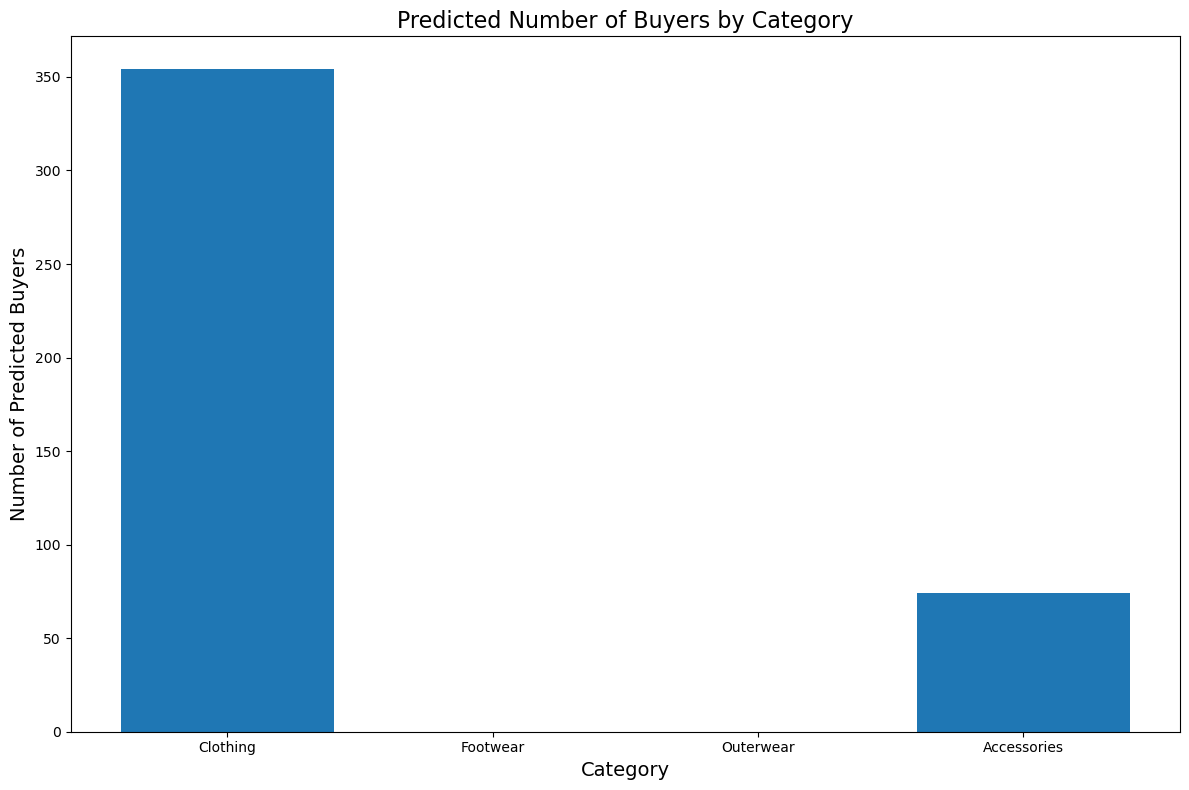

In [35]:
print("RANDOM FOREST --> DETERMINE WHAT TO ADVERTISE")

categories = df['Category'].unique()
for cat in categories:
    df[f'bought_{cat}'] = (df['Category'] == cat).astype(int)


categorical_cols = ['Gender', 'Location', 'Season', 'Frequency of Purchases', 'Payment Method']
for col in categorical_cols:
    le = LabelEncoder()
    df[col + '_encoded'] = le.fit_transform(df[col])


features = ['Age', 'Gender_encoded', 'Purchase Amount (USD)', 'Previous Purchases', 
            'Number of Items Purchased', 'Review Rating', 'Season_encoded']


results = []
confusion_matrices = {}

plt.figure(figsize=(16, 4))
for i, cat in enumerate(categories):
    # Train model for this category
    X = df[features]
    y = df[f'bought_{cat}']
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
    
    rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
    rf_model.fit(X_train, y_train)
    
 
    y_pred = rf_model.predict(X_test)
    
  
    cm = confusion_matrix(y_test, y_pred)
    accuracy = rf_model.score(X_test, y_test)
    feature_importance = rf_model.feature_importances_.mean()
    
    results.append({
        'Category': cat,
        'Accuracy': accuracy,
        'Feature_Importance': feature_importance,
        'Predicted_Buyers': y_pred.sum(),
        'Actual_Buyers': y_test.sum()
    })
    
    confusion_matrices[cat] = cm
    
    plt.subplot(1, 4, i+1)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'{cat}\nAccuracy: {accuracy:.2f}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')

plt.tight_layout()
plt.show()

results_df = pd.DataFrame(results)

print("\nRandom Forest Results for Each Category:")
print(results_df.to_string(index=False))



# predicted buyers
plt.figure(figsize=(12, 8))
bars = plt.bar(results_df['Category'], results_df['Predicted_Buyers'])
plt.title('Predicted Number of Buyers by Category', fontsize=16)
plt.xlabel('Category', fontsize=14)
plt.ylabel('Number of Predicted Buyers', fontsize=14)
plt.tight_layout()
plt.show()
